### **Phase 1: Model Building**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import os
import warnings

In [24]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [25]:
df = pd.read_csv('../data/processed/df_processed.csv')
df.head()

,rcount,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,vmonth,vday_of_week,lengthofstay_log,gender_M,facid_B,facid_C,facid_D,facid_E
0,0,0,0,0,0,0,0,0,0,0,0,0,11.50,14.20,140.36,192.48,12.00,1.39,30.43,96,6.50,4,3,8,2,1.39,False,True,False,False,False
1,5,0,0,0,0,0,0,0,0,0,0,0,9.00,4.10,136.73,94.08,8.00,0.94,28.46,61,6.50,1,7,5,5,2.08,False,False,False,False,False
2,1,0,0,0,0,0,0,0,0,0,0,0,8.40,8.90,133.06,130.53,12.00,1.07,28.84,64,6.50,2,3,9,5,1.39,False,True,False,False,False
3,0,0,0,0,0,0,0,0,0,0,0,0,11.90,9.40,138.99,163.38,12.00,0.91,27.96,76,6.50,1,1,8,3,0.69,False,False,False,False,False
4,0,0,0,0,1,0,1,0,0,0,0,0,9.10,9.05,138.63,94.89,11.50,1.24,30.26,67,5.60,2,4,12,3,1.61,False,False,False,False,True


In [26]:
X = df.drop(columns=['lengthofstay', 'lengthofstay_log'])
y = df['lengthofstay_log']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
pipelines = {
    'Linear Regression': Pipeline([('model', LinearRegression())]),
    'Ridge Regression': Pipeline([('model', Ridge())]),
    'Lasso Regression': Pipeline([('model', Lasso())]),
    'Random Forest': Pipeline([('model', RandomForestRegressor(random_state=42))]),
    'XGBoost': Pipeline([('model', XGBRegressor(random_state=42))]),
    'LightGBM': Pipeline([('model', LGBMRegressor(random_state=42))])
}

In [29]:
param_grids = {
    'Linear Regression': {'model__fit_intercept': [True, False]}, # ใส่กันเหนียวไม่ให้ GridSearch ว่าง
    'Ridge Regression': {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso Regression': {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Random Forest': {'model__n_estimators': [50, 100, 200], 'model__max_depth': [None, 10, 20], 'model__max_features': ['sqrt', 'log2', None], 'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 2, 4]},
    'XGBoost': {'model__n_estimators': [50, 100, 200], 'model__learning_rate': [0.1, 0.2, 0.3], 'model__max_depth': [3, 5, 7], 'model__subsample': [0.8, 1.0], 'model__colsample_bytree': [0.8, 1.0]},
    'LightGBM': {'model__n_estimators': [50, 100, 200], 'model__learning_rate': [0.1, 0.2, 0.3], 'model__num_leaves': [31, 50, 100], 'model__subsample': [0.8, 1.0], 'model__colsample_bytree': [0.8, 1.0]}
}

In [30]:
scoring_metric = {
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error',
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
summary_results = []

In [31]:
for model_name, pipeline in pipelines.items():
    print(f"Training and tuning {model_name}...")
    param_grid = param_grids[model_name]
    n_iter = 20 
    is_tree_model = model_name in ['Random Forest', 'XGBoost', 'LightGBM']

    if is_tree_model:
        search = RandomizedSearchCV(pipeline, param_grid, cv=cv, scoring=scoring_metric, refit='R2', n_iter=20, n_jobs=-1, random_state=42)
    else:
        search = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring_metric, refit='R2', n_jobs=-1)

    search.fit(X_train, y_train)
    best_idx = search.best_index_
    cv_results = search.cv_results_
    r2_mean = cv_results['mean_test_R2'][best_idx]
    r2_std = cv_results['std_test_R2'][best_idx]
    mae_mean = abs(cv_results['mean_test_MAE'][best_idx])
    mae_std = cv_results['std_test_MAE'][best_idx]

    print(f"{model_name} - Best R2: {r2_mean:.4f} ± {r2_std:.4f}, Best MAE: {mae_mean:.4f} ± {mae_std:.4f}")

    summary_results.append({
        'Model': model_name,
        'Best Params': search.best_params_,
        'Best R2': r2_mean,
        'R2 Std': r2_std,
        'Best MAE': mae_mean,
        'MAE Std': mae_std
    })

Training and tuning Linear Regression...
Linear Regression - Best R2: 0.7027 ± 0.0038, Best MAE: 0.2186 ± 0.0014
Training and tuning Ridge Regression...
Ridge Regression - Best R2: 0.7027 ± 0.0038, Best MAE: 0.2186 ± 0.0014
Training and tuning Lasso Regression...
Lasso Regression - Best R2: 0.6627 ± 0.0044, Best MAE: 0.2294 ± 0.0017
Training and tuning Random Forest...
Random Forest - Best R2: 0.9314 ± 0.0014, Best MAE: 0.0824 ± 0.0007
Training and tuning XGBoost...
XGBoost - Best R2: 0.9561 ± 0.0008, Best MAE: 0.0807 ± 0.0004
Training and tuning LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 29
[LightGBM] [Info] Start training from score 1.491388
LightGBM - Best R2: 0.9644 ± 0.0007, Best MAE: 0.0662 ± 0.0009


In [34]:
summary_df = pd.DataFrame(summary_results)
print("\nSummary of Model Performance:")
summary_df.sort_values(by='Best R2', ascending=False)


Summary of Model Performance:


,Model,Best Params,Best R2,R2 Std,Best MAE,MAE Std
5,LightGBM,"{'model__subsample': 1.0, 'model__num_leaves':...",0.96,0.00,0.07,0.00
4,XGBoost,"{'model__subsample': 1.0, 'model__n_estimators...",0.96,0.00,0.08,0.00
3,Random Forest,"{'model__n_estimators': 50, 'model__min_sample...",0.93,0.00,0.08,0.00
1,Ridge Regression,{'model__alpha': 10.0},0.70,0.00,0.22,0.00
0,Linear Regression,{'model__fit_intercept': True},0.70,0.00,0.22,0.00
2,Lasso Regression,{'model__alpha': 0.01},0.66,0.00,0.23,0.00


In [35]:
best_model_name =summary_df.loc[summary_df['Best R2'].idxmax(), 'Model']
best_params = summary_df.loc[summary_df['Best R2'].idxmax(), 'Best Params']
final_pipeline = pipelines[best_model_name]
final_pipeline.set_params(**best_params)
print(f"🌟 เตรียมเทรน Final Model: {best_model_name} ด้วยพารามิเตอร์:")
print(best_params)

🌟 เตรียมเทรน Final Model: LightGBM ด้วยพารามิเตอร์:
{'model__subsample': 1.0, 'model__num_leaves': 50, 'model__n_estimators': 200, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}


In [36]:
final_pipeline.fit(X_train, y_train)   
print(f"✅ Final Model {best_model_name} เทรนเสร็จแล้ว! พร้อมประเมินผลบนชุดทดสอบ...")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 29
[LightGBM] [Info] Start training from score 1.491388
✅ Final Model LightGBM เทรนเสร็จแล้ว! พร้อมประเมินผลบนชุดทดสอบ...


### **Phase 2: Evaluate**

In [39]:
y_pred_log = final_pipeline.predict(X_test)

In [40]:
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [43]:
final_r2 = r2_score(y_test_original, y_pred_original)
print(f"🎯 Final Model Test R2: {final_r2:.4f}")
final_mae = mean_absolute_error(y_test_original, y_pred_original)
print(f"🎯 Final Model Test MAE: {final_mae:.4f}")

🎯 Final Model Test R2: 0.9682
🎯 Final Model Test MAE: 0.2953


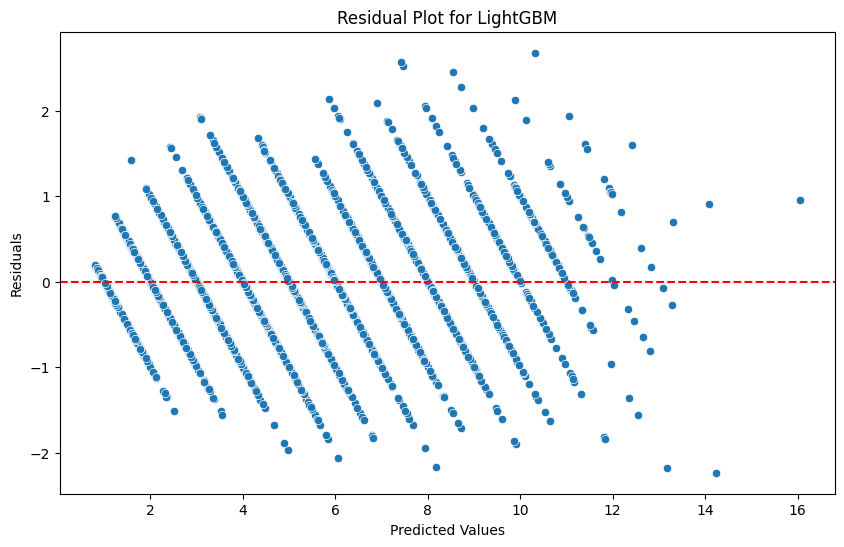

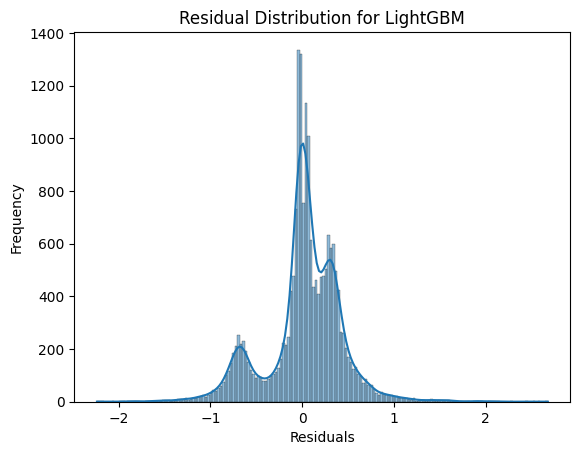

In [44]:
residuals = y_test_original - y_pred_original
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_original, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Residual Plot for {best_model_name}')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

sns.histplot(residuals, kde=True)
plt.title(f'Residual Distribution for {best_model_name}')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

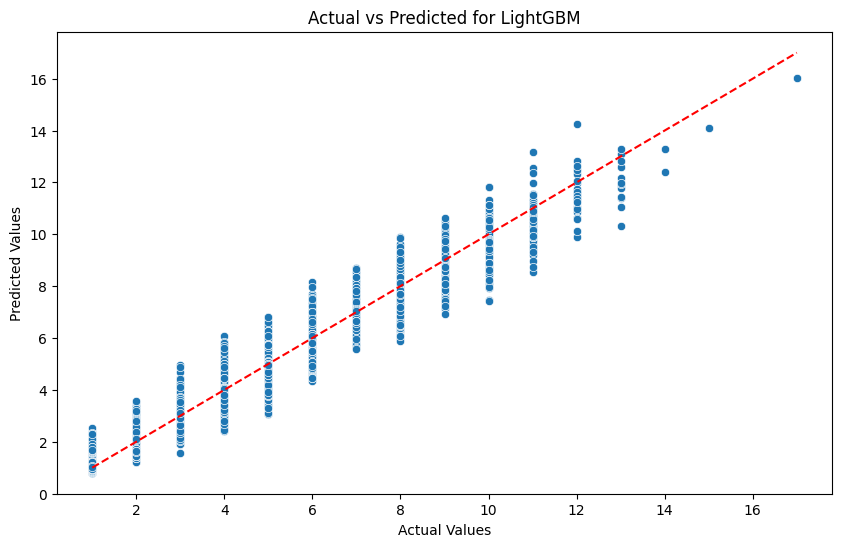

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original, y=y_pred_original)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
plt.title(f'Actual vs Predicted for {best_model_name}')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

### **Phase 3: Model Deployment**


In [46]:
import joblib

In [ ]:
model_filename = '../models/lengthofstay_final_model.joblib'
joblib.dump(final_pipeline, model_filename)

['../model/lengthofstay_final_model.joblib']

In [ ]:
model_columns = list(X.columns)
joblib.dump(model_columns, '../models/model_columns.joblib')

['../model/model_columns.joblib']